#### ESN NOTEBOOK

#### Sin Wave test with only feedback

In [ ]:
## Defining the network and the update rule
import numpy as np
from numpy.linalg import eigvals
from numpy import typing as npt
from typing import Annotated, Literal
import matplotlib.pyplot as plt
rng = np.random.default_rng(seed=42)

N = 100 #internal units
K = 1   #input units
L = 1   #output units

#Weights. N internal units. 1 input unit. 1 output unit.

W = rng.choice([0,-0.4,0.4],size=[N,N],p=[0.95,0.025,0.025])

eigval = eigvals(W)
print('|lambda_max| =',abs(max(eigval)))

W_in = rng.choice([-1,1],size=[N,K])  #input connections


# Update rule
def update(x,u) -> npt.NDArray[np.float64]:
    x = np.tanh(W_in @ u + W @ x)
    return x 

#Output
def output(W_out,x,u,y,f=None) -> npt.NDArray[np.float64]:
    a = np.concatenate((x,u,y),axis=0)
    if f is None:
        return W_out @ a
    else:
        return f(W_out @ a)

In [ ]:
# Data Generation
washout, train, test = 101, 200, 1000
total_steps = washout+train+test
n = np.linspace(1,total_steps,total_steps)
u = np.sin(n/5)
y = u**7
u_ = np.zeros(total_steps)
u_[1:] = y[:-1]
noise = rng.uniform(low=-1e-3,high=1e-3,size=washout+train)
s_washout = u_[:washout] + noise[:washout]
s_train = u_[washout:washout+train] + noise[washout:washout+train]

In [ ]:
# Run
## Washout Phase
x = np.zeros([N,1])
for s_val in s_washout:
    x = update(x,s_val.reshape(K,1))

## Training Phase
X = np.zeros([train,N])
for k in range(train):
    x = update(x,s_train[k].reshape(K,1))
    X[k,:] = x[:,0]

In [ ]:
# Plot
fig, ax = plt.subplots(3,4,figsize=(10,5), gridspec_kw={'wspace': 0.05, 'hspace': 0.05})
#unit_idx = np.array([[0,11,21,31],[51,61,71,81]])
unit_idx = rng.choice(100,size=[3,4])
print(unit_idx)
for i in range(3):
    for j in range(4):
        ax[i,j].plot(X[:,unit_idx[i,j]])
        ax[i,j].set_xlim(0,157.1)
        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])

In [ ]:
# Fit
from sklearn.linear_model import LinearRegression, Ridge
model = LinearRegression()
#model = Ridge(alpha=1e-8)
model.fit(X,y[washout:washout+train])

In [ ]:
y_train_pred = model.predict(X)
mse_train = np.mean((y[washout:washout+train]-y_train_pred)**2)
print(f'mse_train = {mse_train}')

In [ ]:
y_test_pred = np.zeros(test)
y_test_pred[0] = model.predict(X[-1,:].reshape(1,-1))[0]
for k in range(1,test):
    x = update(x,y_test_pred[k-1].reshape(K,1))
    y_test_pred[k] = model.predict(x.reshape(1,-1))[0]

In [ ]:
plt.figure(figsize=[16,5])
plt.plot(y_test_pred)
plt.plot(y[washout+train-1:washout+train+test-1])

In [ ]:
mse_test_100 = np.mean((y[washout+train-1:washout+train+100-1]-y_test_pred[:100])**2)
mse_test = np.mean((y[washout+train-1:washout+train+test-1]-y_test_pred)**2)
print(f'mse_test_100 = {mse_test_100}')
print(f'mse_test = {mse_test}')

#### Discrete Periodic Sequence Learning

In [1]:
# Defining the network and the update rule
import numpy as np
from numpy.linalg import eigvals
from numpy import typing as npt
from typing import Annotated, Literal
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
rng = np.random.default_rng(seed=42)

N = 400 #internal units
K = 1   #input units
L = 1   #output units

#Weights. N internal units. 1 input unit. 1 output unit.

W = rng.choice([0,-0.4,0.4],size=[N,N],p=[0.9875,0.00625,0.00625])

eigval = eigvals(W)
print('|lambda_max| =',abs(max(eigval)))


W_back = rng.choice([-2,2],size=[N,L])   # feedback weights


# Update rule
def update(x,y,v=0,W=W,W_back=W_back) -> npt.NDArray[np.float64]:
    if v==0:x = np.tanh(W @ x + W_back @ y)
    else: x = np.tanh(W @ x + W_back @ (y+v))
    return x 

# Output
def output(W_out,x,u,y,f=None) -> npt.NDArray[np.float64]:
    a = np.concatenate((x,u,y),axis=0)
    if f is None:
        return W_out @ a
    else:
        return f(W_out @ a)

|lambda_max| = 0.900872368514349


In [2]:
# Response to a unit impulse (Needs the complete version of the update rule. Would not run with what is currently defined.)
#u = np.zeros(100)
#u[10] = 1
#y = np.zeros([L,1])
#x = np.zeros([N,1])
#X = np.zeros([len(u),N])
#for k in range(len(u)):
#    x = update(u[k].reshape(K,1),x,y)
#    X[k,:] = x[:,0]

# Plot
#fig, ax = plt.subplots(3,4,figsize=(10,5), gridspec_kw={'wspace': 0.05, 'hspace': 0.05})
#unit_idx = rng.choice(400,size=[3,4])
#print(unit_idx)
#for i in range(3):
#    for j in range(4):
#        ax[i,j].plot(X[:,unit_idx[i,j]])
#        ax[i,j].set_xticks([])
#        ax[i,j].set_yticks([])

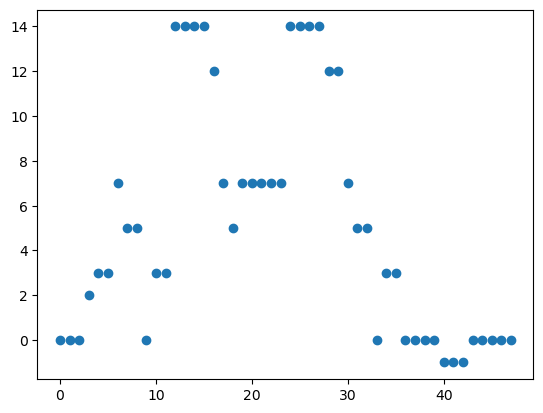

In [3]:
# Generating Data (House of the rising sun)
steps = range(48)
melody = np.array([0,0,0,2,3,3,7,5,5,0,3,3,14,14,14,14,12,7,5,7,7,7,7,7,14,14,14,14,12,12,7,5,5,0,3,3,0,0,0,0,-1,-1,-1,0,0,0,0,0])
plt.scatter(steps,melody)
melody = melody/28

washout = 500
train = 1000
y = np.zeros(washout+train)
for i in range(washout+train):
    y[i] = melody[i%48]

In [4]:
# Training
x = np.zeros([N,1])
# washout
for k in range(washout):
    x = update(x,y[k].reshape(L,1))

# training
X = np.zeros([train,N])
X[0,:] = x[:,0]
for k in range(train-1):
    x = update(x,y[washout+k].reshape(L,1))
    X[1+k,:] = x[:,0]

In [5]:
# Fit
model = LinearRegression()
model.fit(X,np.arctanh(y[washout:washout+train]))

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
# training error
y_train_out = np.tanh(model.predict(X))
mse_train = np.mean((y[washout:washout+train] - y_train_out)**2)
print(f'mse_train = {mse_train}')

mse_train = 1.0465116735512152e-29


In [7]:
# prediction
teacher = 500
pred = 300

x = np.zeros([N,1])
# teacher forcing
for k in range(teacher):
    x = update(x,y[k].reshape(L,1))

y_out = np.zeros(pred)
y_out[0] = np.tanh(model.predict(x.reshape(1,-1))[0])
# free running
for k in range(1,pred):
    x = update(x,y_out[k-1].reshape(L,1))
    y_out[k] = np.tanh(model.predict(x.reshape(1,-1))[0])

(-0.6, 0.8)

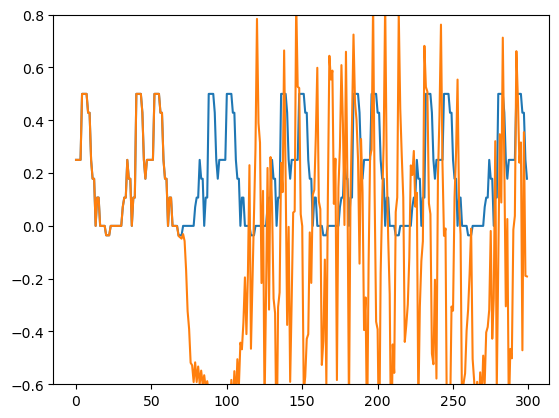

In [8]:
plt.plot(y[teacher:teacher+pred])
plt.plot(y_out)
plt.ylim(-0.6,0.8)